Warning leverage h* = 0.057



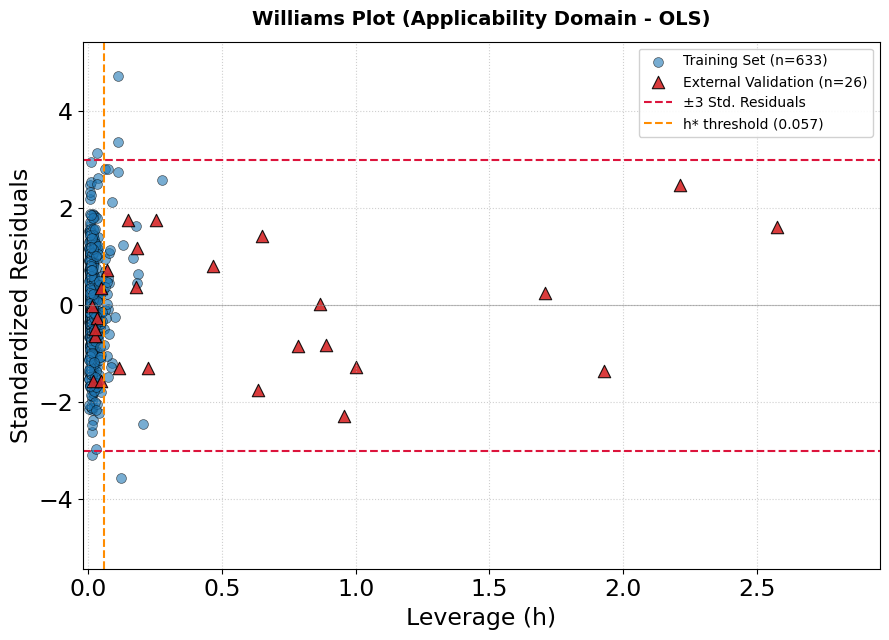

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Configuration Section (Requires training and validation datasets)
# ==========================================
TRAIN_FILE = r'C:\Users\Lenovo\Desktop\威廉图\主数据表-威廉图.xlsx'
TEST_FILE = r"C:\Users\Lenovo\Desktop\威廉图\外部验证数据-威廉图.xlsx"

FEATURE_COLS = ['lumo','homo','Charge', 'AN','EN','Density','DP', 'disp','BV','ANN','ENN'] 
TARGET_COL = 'y'

# Read data
df_train = pd.read_excel(TRAIN_FILE)
df_test = pd.read_excel(TEST_FILE)

X_train0 = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values

X_test0 = df_test[FEATURE_COLS].values
y_test = df_test[TARGET_COL].values

# ==========================================
# 2. Feature Space Construction & Leverage (h) Calculation (Strictly based on training set)
# ==========================================
# Add constant term
X_train = sm.add_constant(X_train0)
# Ensure the validation set also has a constant term to match the training set dimensions
X_test = sm.add_constant(X_test0, has_constant='add')

n_train, p = X_train.shape

# Calculate the (X^T * X)^(-1) matrix using only the training set
XtX_inv = np.linalg.inv(np.dot(X_train.T, X_train))

# Calculate leverage values for the training set
h_train = np.sum(np.dot(X_train, XtX_inv) * X_train, axis=1)

# Project the external validation set onto the training set feature space to calculate leverage
h_test = np.sum(np.dot(X_test, XtX_inv) * X_test, axis=1)

# Calculate the warning leverage h* (Determined only by training set parameters)
h_star = 3 * p / n_train
print(f"Warning leverage h* = {h_star:.3f}\n")

# ==========================================
# 3. Multiple Linear Regression Fitting and Prediction
# ==========================================
# Fit the linear regression model using only the training set
model = sm.OLS(y_train, X_train).fit()

# Extract model standard deviation s (model.scale is variance, needs square root)
s = np.sqrt(model.scale) 

# Calculate predictions for training and validation sets respectively
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate standardized residuals (use np.maximum to prevent division by zero when h is close to 1)
std_resid_train = (y_train - y_train_pred) / (s * np.sqrt(np.maximum(1e-6, 1 - h_train)))
# std_resid_test = (y_test - y_test_pred) / (s * np.sqrt(np.maximum(1e-6, 1 - h_test)))
std_resid_test = (y_test - y_test_pred) / (s * np.sqrt(1 + h_test))

# ==========================================
# 4. Plot Williams Plot (Applicability Domain)
# ==========================================
plt.figure(figsize=(9, 6.5), dpi=100)

# Plot training set
plt.scatter(h_train, std_resid_train, color='#1f77b4', alpha=0.6, 
            edgecolors='k', linewidths=0.5, s=50, label=f'Training Set (n={n_train})')

# Plot external validation set
plt.scatter(h_test, std_resid_test, color='#d62728', marker='^', alpha=0.9, 
            edgecolors='k', linewidths=0.8, s=80, label=f'External Validation (n={len(y_test)})')

# Plot residual warning lines (±3)
plt.axhline(y=3, color='crimson', linestyle='--', linewidth=1.5, label='±3 Std. Residuals')
plt.axhline(y=-3, color='crimson', linestyle='--', linewidth=1.5)

# Plot leverage warning line (h*)
plt.axvline(x=h_star, color='darkorange', linestyle='--', linewidth=1.5, label=f'h* threshold ({h_star:.3f})')

# Auxiliary line y=0
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Chart formatting and labels
plt.title("Williams Plot (Applicability Domain - OLS)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Leverage (h)", fontsize=17)
plt.ylabel("Standardized Residuals", fontsize=17)

# === Adjust axis tick label sizes here ===
plt.tick_params(axis='both', labelsize=17)  # 'labelsize' controls the font size of the tick numbers

# Dynamic axis ranges
max_h = max(max(h_train), max(h_test), h_star) * 1.15
max_res = max(max(abs(std_resid_train)), max(abs(std_resid_test)), 3.5) * 1.15
plt.xlim(-0.02, max_h)
plt.ylim(-max_res, max_res)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()